# 미니프로젝트: 차원 축소와 SHAP Value (Vibe Coding)

#### <목표>
오늘 배운 **mRMR, Boruta, SHAP Value**를 **통신사 고객 이탈(Customer Churn) 데이터셋**에 적용해 봅니다.

**Cursor AI**를 활용하여 각 단계의 코드를 직접 생성하고 실행해 보세요.

#### <데이터셋 소개>

| 변수명 | 설명 |
|:---:|:---|
| gender, SeniorCitizen, Partner, Dependents | 고객 인적사항 |
| tenure | 가입 개월 수 |
| PhoneService, MultipleLines, InternetService 등 | 가입 서비스 종류 |
| Contract, PaperlessBilling, PaymentMethod | 계약/결제 정보 |
| MonthlyCharges, TotalCharges | 월/누적 요금 |
| Churn | 이탈 여부 (Yes: 이탈, No: 유지) |

#### <실습 태스크>
| 태스크 | 타겟 변수 | 설명 |
|:---:|:---:|:---|
| 분류 | `Churn` | 인코딩된 고객 정보로 이탈 여부 예측 및 변수 해석 |

1. 각 섹션의 **과제**를 읽고, 어떤 고민/결정이 필요한지 먼저 생각해 봅니다.
2. 빈 코드 셀을 클릭한 후 Cursor AI 채팅창을 엽니다.
3. 막막한 부분은 AI와 상의해서 방법을 정하고, 그 방법으로 프롬프트를 작성합니다.
4. 생성된 코드를 실행하고 결과를 확인합니다.

## 0) 분석 준비

- `dataset/day5_miniproject.csv` 파일을 사용하기
- 타겟 변수: `Churn` (No: 유지, Yes: 이탈)
- 지난 미니프로젝트에서 다룬 전처리를 모두 적용한 뒤 시작하세요.

**[과제]** 써니는 어제 실습에서 사용한 통신사 고객 이탈(Churn) 데이터를 활용하여 분석을 진행하고자 합니다. 필요한 라이브러리와 데이터를 불러오세요.

In [18]:
#한글폰트
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

plt.rcParams["font.family"] = "AppleGothic"   # macOS 기본 한글 폰트
plt.rcParams["axes.unicode_minus"] = False     # 마이너스 기호 깨짐 방지

In [ ]:
# 기본
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["font.family"] = "Malgun Gothic"   # Windows 한글 폰트
plt.rcParams["axes.unicode_minus"] = False

# 머신러닝
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import KNNImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
)

# 변수 선택 & 해석 (이후 섹션에서 사용)
# !pip install mrmr-selection boruta shap
from mrmr import mrmr_classif
from boruta import BorutaPy
import shap

In [2]:
# 데이터 불러오기
data = pd.read_csv("dataset/day5_miniproject.csv")

# 기본 정보 확인
print("데이터 크기:", data.shape)
print("\n컬럼 목록:")
print(data.columns.tolist())

data.head()

데이터 크기: (7043, 20)

컬럼 목록:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1.0,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34.0,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2.0,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45.0,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2.0,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


**[과제]** 써니는 어제 진행한 통신사 고객 이탈 데이터 전처리 과정을 재사용하고자 합니다. Agent 기능을 활용하여 '머신러닝 Day4. 미니프로젝트.ipynb' 파일에서 전처리 코드를 찾아 실행하고 동일한 데이터 전처리 결과를 재현해 보세요.

> 입력변수, 출력변수 분할 / 학습 데이터, 테스트 데이터 분할 / 결측치 처리 / 스케일링, 인코딩

In [3]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer

# ── 0) 데이터 로드 ──
data = pd.read_csv("dataset/day5_miniproject.csv")

# ── 1) 기본 정제 ──
data_clean = data.drop_duplicates().copy()
data_clean["Churn"] = data_clean["Churn"].map({"No": 0, "Yes": 1})

# TotalCharges: object → float 변환 (공백 결측 포함)
data_clean["TotalCharges"] = pd.to_numeric(data_clean["TotalCharges"], errors="coerce")

# ── 2) 결측치 처리 ──
data_imp = data_clean.copy()

# TotalCharges: 신규 고객(tenure=0) → MonthlyCharges로 대치
mask = data_imp["TotalCharges"].isnull()
data_imp.loc[mask, "TotalCharges"] = data_imp.loc[mask, "MonthlyCharges"]

# 범주형: 최빈값
for col in data_imp.select_dtypes(include="object").columns:
    data_imp[col] = data_imp[col].fillna(data_imp[col].mode()[0])

# 수치형: KNN Imputer
imputer = KNNImputer(n_neighbors=5)
num_cols = ["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges"]
data_imp[num_cols] = imputer.fit_transform(data_imp[num_cols])

# ── 3) 이상치 처리 (Winsorization: 상·하위 1% clip, 행 유지) ──
data_out = data_imp.copy()
for col in ["tenure", "MonthlyCharges", "TotalCharges"]:
    lower, upper = data_out[col].quantile(0.01), data_out[col].quantile(0.99)
    data_out[col] = data_out[col].clip(lower, upper)

# ── 4) 입력(X) / 출력(Y) 분할 ──
X = data_out.drop("Churn", axis=1)
Y = data_out["Churn"]

# ── 5) 학습 / 테스트 분할 (stratify로 클래스 비율 유지) ──
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42, stratify=Y
)

# ── 6) 인코딩 + 스케일링 ──
cat_cols = X_train.select_dtypes(include="object").columns.tolist()
num_cols = X_train.select_dtypes(include="number").columns.tolist()

# One-Hot Encoding
X_train_enc = pd.get_dummies(X_train, columns=cat_cols, drop_first=True)
X_test_enc  = pd.get_dummies(X_test,  columns=cat_cols, drop_first=True)
X_test_enc  = X_test_enc.reindex(columns=X_train_enc.columns, fill_value=0)

# StandardScaler (수치형만)
scaler = StandardScaler()
X_train_scaled = X_train_enc.copy()
X_test_scaled  = X_test_enc.copy()

X_train_scaled[num_cols] = scaler.fit_transform(X_train_enc[num_cols])
X_test_scaled[num_cols]  = scaler.transform(X_test_enc[num_cols])

# ── 7) 확인 ──
print("전처리 후 데이터:", data_out.shape)
print("학습:", X_train_scaled.shape, "| 테스트:", X_test_scaled.shape)
print("Churn 비율 (train):", Y_train.value_counts(normalize=True).round(3).to_dict())
print("남은 결측치:", data_out.isnull().sum().sum())
X_train_scaled.head()

전처리 후 데이터: (7025, 20)
학습: (5620, 30) | 테스트: (1405, 30)
Churn 비율 (train): {0: 0.735, 1: 0.265}
남은 결측치: 0


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
2982,-0.43984,0.799183,-1.479657,-0.539058,True,True,True,True,False,False,...,True,False,True,False,True,False,True,True,False,False
3695,-0.43984,-0.017949,1.128783,0.352461,False,True,True,True,False,True,...,False,True,False,True,False,False,True,False,True,False
5806,-0.43984,-1.243648,-1.521459,-0.996636,False,False,True,True,False,False,...,True,False,True,False,False,False,True,False,True,False
155,-0.43984,-0.753369,0.528507,-0.503186,False,True,True,True,False,False,...,False,False,False,True,False,False,True,False,False,False
460,-0.43984,-1.080222,-1.519787,-0.967898,True,False,True,True,False,False,...,True,False,True,False,False,False,False,False,False,True


## 1) 다중공선성 확인

**[과제]** 써니는 인코딩된 변수들의 상관행렬을 히트맵으로 그려보고 어떤 변수끼리 상관관계가 높은지 AI와 함께 확인해 보세요.

findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font famil

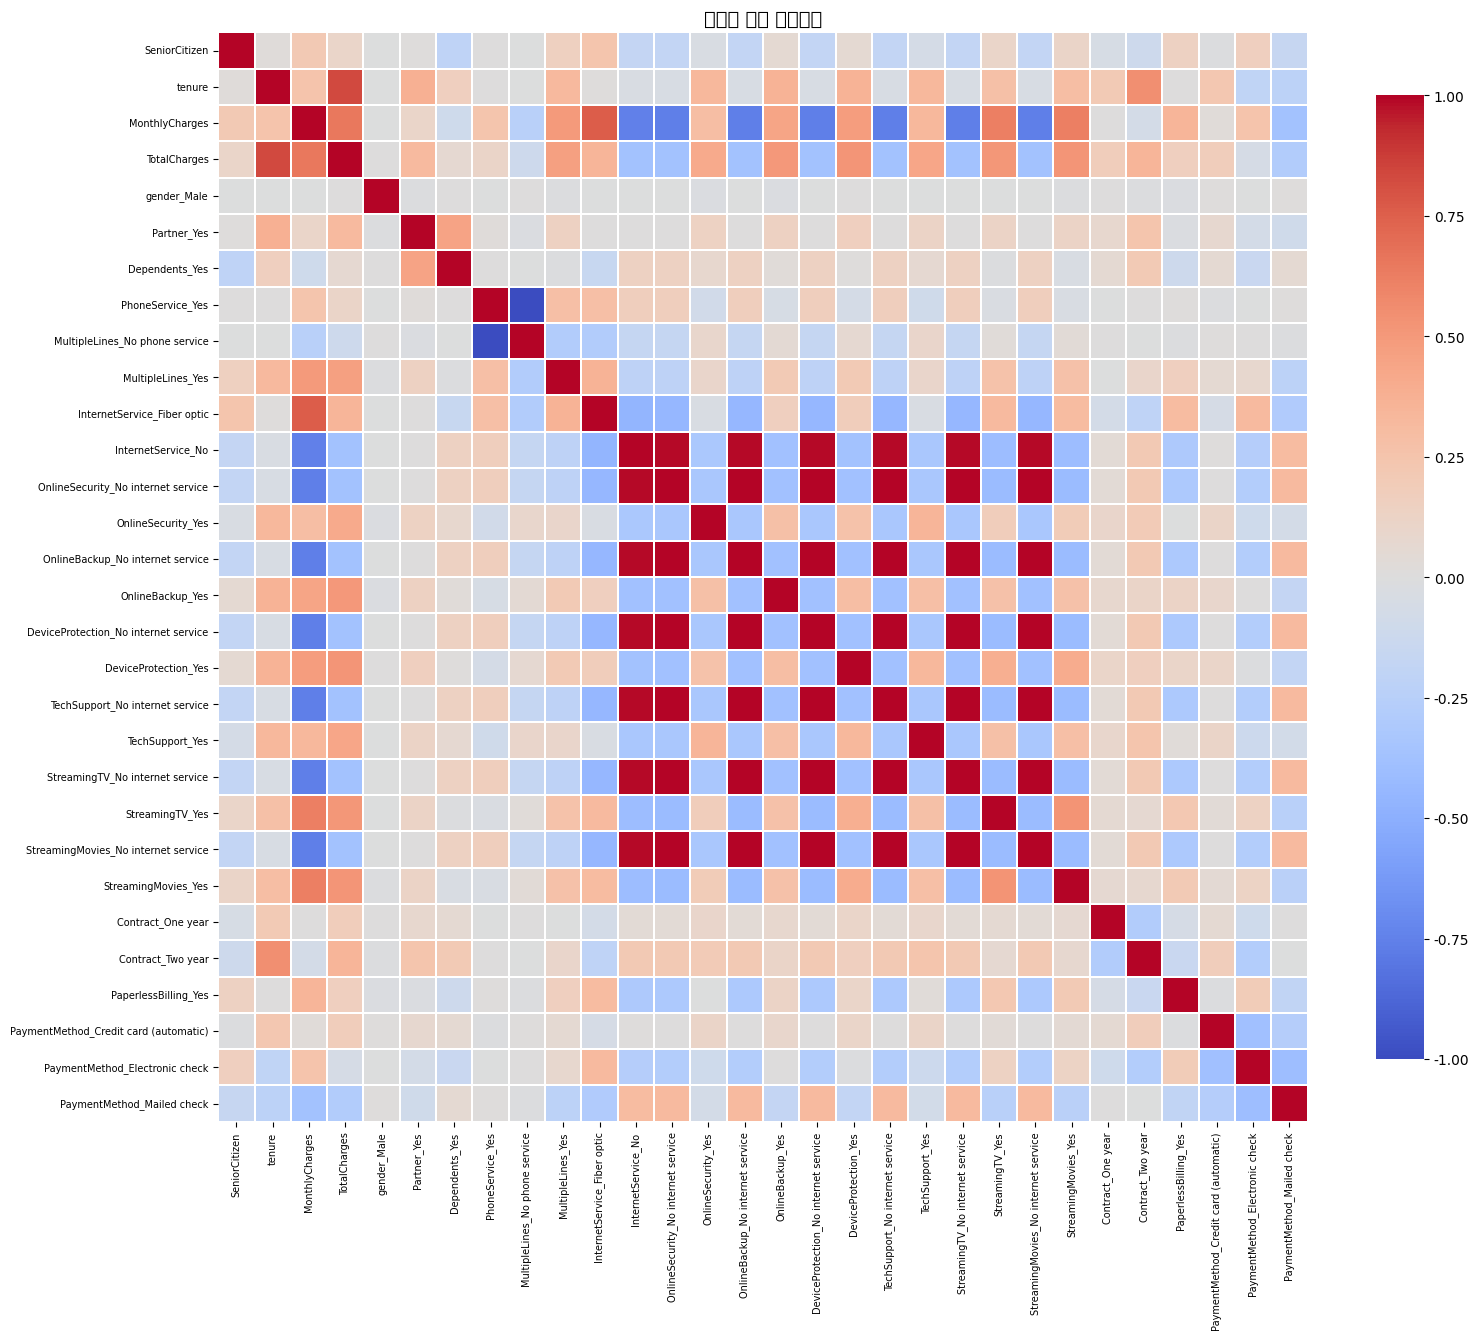

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 상관행렬 계산
corr_matrix = X_train_scaled.corr()

# 히트맵 (전체 변수)
plt.figure(figsize=(16, 14))
sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.3,
    cbar_kws={"shrink": 0.8}
)
plt.title("인코딩 변수 상관행렬", fontsize=14)
plt.xticks(rotation=90, fontsize=7)
plt.yticks(rotation=0, fontsize=7)
plt.tight_layout()
plt.show()

In [5]:
# 상관 높은 변수 쌍 Top 15 (자기 자신 제외)
pairs = []
cols = corr_matrix.columns
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        pairs.append((cols[i], cols[j], corr_matrix.iloc[i, j]))

corr_pairs = (
    pd.DataFrame(pairs, columns=["변수1", "변수2", "상관계수"])
    .assign(절대값=lambda d: d["상관계수"].abs())
    .sort_values("절대값", ascending=False)
    .drop(columns="절대값")
)

print("상관 Top 15:")
display(corr_pairs.head(15))

상관 Top 15:


,변수1,변수2,상관계수
291,OnlineSecurity_No internet service,StreamingMovies_No internet service,1.0
322,OnlineBackup_No internet service,StreamingMovies_No internet service,1.0
391,StreamingTV_No internet service,StreamingMovies_No internet service,1.0
287,OnlineSecurity_No internet service,TechSupport_No internet service,1.0
316,OnlineBackup_No internet service,DeviceProtection_No internet service,1.0
349,DeviceProtection_No internet service,StreamingMovies_No internet service,1.0
285,OnlineSecurity_No internet service,DeviceProtection_No internet service,1.0
370,TechSupport_No internet service,StreamingTV_No internet service,1.0
283,OnlineSecurity_No internet service,OnlineBackup_No internet service,1.0
318,OnlineBackup_No internet service,TechSupport_No internet service,1.0


**[과제]** 써니는 변수 선택법과 SHAP 분석을 적용하기 전에 전체 변수를 사용한 Random Forest 분류 모델의 성능을 기준으로 삼고자 합니다. AI와 상의하여 모델을 학습하고, Accuracy, Precision, Recall, F1-score를 계산하여 성능을 확인하는 코드를 작성해 보세요.

In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

# 1) 모델 학습 (전체 30개 변수)
rf_full = RandomForestClassifier(n_estimators=100, random_state=42)
rf_full.fit(X_train_scaled, Y_train)

# 2) 예측
Y_pred = rf_full.predict(X_test_scaled)

# 3) 성능 평가
print(f"사용 변수 수: {X_train_scaled.shape[1]}")
print(f"Accuracy  : {accuracy_score(Y_test, Y_pred):.3f}")
print(f"Precision : {precision_score(Y_test, Y_pred):.3f}")
print(f"Recall    : {recall_score(Y_test, Y_pred):.3f}")
print(f"F1-score  : {f1_score(Y_test, Y_pred):.3f}")

# 4) 혼동행렬
print("\n[혼동행렬]")
print(confusion_matrix(Y_test, Y_pred))

# 5) 상세 리포트
print("\n[Classification Report]")
print(classification_report(Y_test, Y_pred, target_names=["No Churn(0)", "Churn(1)"]))

사용 변수 수: 30
Accuracy  : 0.784
Precision : 0.625
Recall    : 0.465
F1-score  : 0.533

[혼동행렬]
[[929 104]
 [199 173]]

[Classification Report]
              precision    recall  f1-score   support

 No Churn(0)       0.82      0.90      0.86      1033
    Churn(1)       0.62      0.47      0.53       372

    accuracy                           0.78      1405
   macro avg       0.72      0.68      0.70      1405
weighted avg       0.77      0.78      0.77      1405



## 2) mRMR 변수 선택

**[과제]** 써니는 mRMR을 활용해 중요한 변수를 선택해보고자 합니다. AI와 상의해서 가장 적합한 k를 결정하고 선택된 변수로 모델을 다시 학습시켜 전체 변수를 사용했을 때 때와 성능을 비교해 보세요.

In [7]:
from mrmr import mrmr_classif
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

# Churn(불균형) → F1 기준으로 k 선택
k_candidates = [3, 5, 7, 10, 12, 15, 20]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

k_scores = {}
selected_by_k = {}

for k in k_candidates:
    # mRMR 변수 선택 (분류용)
    selected = mrmr_classif(
        X=X_train_scaled, y=Y_train, K=k,
        n_jobs=1, show_progress=False   # Jupyter에서 오류 나면 n_jobs=1 사용
    )
    selected_by_k[k] = selected

    X_tr = X_train_scaled[selected]
    rf_cv = RandomForestClassifier(n_estimators=100, random_state=42)

    cv_f1 = cross_val_score(rf_cv, X_tr, Y_train, cv=cv, scoring="f1")
    k_scores[k] = cv_f1.mean()

    print(f"k={k:2d} | CV F1={cv_f1.mean():.3f} | 변수={selected}")

# CV F1이 가장 높은 k 선택
best_k = max(k_scores, key=k_scores.get)
selected_mrmr = selected_by_k[best_k]

print(f"\n최적 k: {best_k} (CV F1={k_scores[best_k]:.3f})")
print(f"mRMR 선택 변수 ({len(selected_mrmr)}개):", selected_mrmr)

k= 3 | CV F1=0.523 | 변수=['tenure', 'PaperlessBilling_Yes', 'InternetService_Fiber optic']
k= 5 | CV F1=0.539 | 변수=['tenure', 'PaperlessBilling_Yes', 'InternetService_Fiber optic', 'PaymentMethod_Electronic check', 'Contract_Two year']
k= 7 | CV F1=0.533 | 변수=['tenure', 'PaperlessBilling_Yes', 'InternetService_Fiber optic', 'PaymentMethod_Electronic check', 'Contract_Two year', 'Contract_One year', 'OnlineSecurity_No internet service']
k=10 | CV F1=0.526 | 변수=['tenure', 'PaperlessBilling_Yes', 'InternetService_Fiber optic', 'PaymentMethod_Electronic check', 'Contract_Two year', 'Contract_One year', 'OnlineSecurity_No internet service', 'Dependents_Yes', 'OnlineSecurity_Yes', 'SeniorCitizen']
k=12 | CV F1=0.530 | 변수=['tenure', 'PaperlessBilling_Yes', 'InternetService_Fiber optic', 'PaymentMethod_Electronic check', 'Contract_Two year', 'Contract_One year', 'OnlineSecurity_No internet service', 'Dependents_Yes', 'OnlineSecurity_Yes', 'SeniorCitizen', 'OnlineBackup_No internet service', 'Pa

In [8]:
# ── mRMR 선택 변수 모델 ──
X_train_mrmr = X_train_scaled[selected_mrmr]
X_test_mrmr  = X_test_scaled[selected_mrmr]

rf_mrmr = RandomForestClassifier(n_estimators=100, random_state=42)
rf_mrmr.fit(X_train_mrmr, Y_train)
Y_pred_mrmr = rf_mrmr.predict(X_test_mrmr)

# ── 전체 변수 모델 (Baseline, 이미 학습했다면 rf_full / Y_pred 재사용) ──
# rf_full.fit(X_train_scaled, Y_train)
# Y_pred_full = rf_full.predict(X_test_scaled)

def get_metrics(y_true, y_pred):
    return {
        "Accuracy":  accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall":    recall_score(y_true, y_pred),
        "F1-score":  f1_score(y_true, y_pred),
    }

compare_df = pd.DataFrame({
    "전체 변수 (30개)": get_metrics(Y_test, Y_pred),
    f"mRMR (k={best_k}, {len(selected_mrmr)}개)": get_metrics(Y_test, Y_pred_mrmr),
}).T.round(3)

print(compare_df)

                Accuracy  Precision  Recall  F1-score
전체 변수 (30개)        0.784      0.625   0.465     0.533
mRMR (k=5, 5개)     0.769      0.579   0.473     0.521


## 3) Boruta 변수 선택

**[과제]** 써니는 Boruta로도 변수를 선택해보고자 합니다. AI와 상의하여 관련 코드를 작성하세요.

In [9]:
from boruta import BorutaPy
from sklearn.ensemble import RandomForestClassifier

# 분류용 Random Forest (Day 5-1: Regressor → Classifier)
rf_boruta = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=1)

# Boruta 설정
# - n_estimators='auto' : shadow feature 비교용 트리 수 자동
# - max_iter=100        : 반복 판단 횟수 (많을수록 정확, 느림)
# - perc=100            : 판단 기준 (100=가장 엄격)
boruta_selector = BorutaPy(
    rf_boruta,
    n_estimators="auto",
    max_iter=100,
    perc=100,
    random_state=42
)

# BorutaPy는 numpy 배열만 지원
boruta_selector.fit(X_train_scaled.values, Y_train.values.ravel())

print("총 변수:", X_train_scaled.shape[1])
print("Boruta 확정 변수:", boruta_selector.n_features_)

총 변수: 30
Boruta 확정 변수: 3


In [10]:
# Boruta 3가지 상태
# support_      : 확정 (Confirmed) — 유의미
# support_weak_ : 미정 (Tentative) — 애매
# 둘 다 False   : 기각 (Rejected)

boruta_cols = X_train_scaled.columns[boruta_selector.support_].tolist()
boruta_tentative = X_train_scaled.columns[boruta_selector.support_weak_].tolist()
boruta_rejected = X_train_scaled.columns[
    ~boruta_selector.support_ & ~boruta_selector.support_weak_
].tolist()

# 미정 변수는 RF 중요도 순으로 정렬 (추가 포함 여부 판단용)
rf_imp = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=1)
rf_imp.fit(X_train_scaled, Y_train)
importances = rf_imp.feature_importances_

tentative_ranked = sorted(
    boruta_tentative,
    key=lambda c: importances[X_train_scaled.columns.get_loc(c)],
    reverse=True
)

print("확정 변수:", boruta_cols)
print("미정 변수(중요도 순):", tentative_ranked)
print("기각 변수 수:", len(boruta_rejected))

확정 변수: ['tenure', 'MonthlyCharges', 'TotalCharges']
미정 변수(중요도 순): []
기각 변수 수: 27


In [13]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
tentative_scores = {}

max_add = min(5, len(tentative_ranked))  # 미정 변수 최대 5개까지 추가 테스트

for n in range(0, max_add + 1):
    cols = boruta_cols + tentative_ranked[:n]
    rf_cv = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=1)
    cv_f1 = cross_val_score(rf_cv, X_train_scaled[cols], Y_train, cv=cv, scoring="f1")
    tentative_scores[n] = cv_f1.mean()
    print(f"미정 {n}개 추가 | CV F1={cv_f1.mean():.3f} | 변수={cols}")

# CV F1 최고인 조합 선택 (미정 0개면 boruta_cols만 사용)
best_n = max(tentative_scores, key=tentative_scores.get) if tentative_scores else 0
selected_boruta = boruta_cols + tentative_ranked[:best_n]

print(f"\n최종 Boruta 변수 ({len(selected_boruta)}개):", selected_boruta)

미정 0개 추가 | CV F1=0.494 | 변수=['tenure', 'MonthlyCharges', 'TotalCharges']

최종 Boruta 변수 (3개): ['tenure', 'MonthlyCharges', 'TotalCharges']


In [14]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

# Boruta 선택 변수로 학습
X_train_boruta = X_train_scaled[selected_boruta]
X_test_boruta  = X_test_scaled[selected_boruta]

rf_boruta_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_boruta_model.fit(X_train_boruta, Y_train)
Y_pred_boruta = rf_boruta_model.predict(X_test_boruta)

# 성능 비교 (rf_full / Y_pred는 Baseline 셀 결과 재사용)
def get_metrics(y_true, y_pred):
    return {
        "Accuracy":  accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall":    recall_score(y_true, y_pred),
        "F1-score":  f1_score(y_true, y_pred),
    }

compare_df = pd.DataFrame({
    "전체 변수 (30개)": get_metrics(Y_test, Y_pred),
    f"Boruta ({len(selected_boruta)}개)": get_metrics(Y_test, Y_pred_boruta),
}).T.round(3)

print(compare_df)

             Accuracy  Precision  Recall  F1-score
전체 변수 (30개)     0.784      0.625   0.465     0.533
Boruta (3개)     0.757      0.550   0.446     0.493


## 4) 성능 비교 요약

**[과제]** 써니는 전체 변수/mRMR/Boruta 세 가지 방법의 성능을 표로 정리하고 변수 수를 줄였을 때 성능이 어떻게 변하는지 AI와 함께 해석해 보세요.

In [15]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def get_metrics(y_true, y_pred):
    return {
        "Accuracy":  accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall":    recall_score(y_true, y_pred),
        "F1-score":  f1_score(y_true, y_pred),
    }

# ── (A) 이미 학습한 모델 결과가 있을 때 ──
compare_df = pd.DataFrame({
    "Method": [
        f"전체 변수 ({X_train_scaled.shape[1]}개)",
        f"mRMR (k={best_k}, {len(selected_mrmr)}개)",
        f"Boruta ({len(selected_boruta)}개)",
    ],
    "변수 수": [
        X_train_scaled.shape[1],
        len(selected_mrmr),
        len(selected_boruta),
    ],
    **{k: [
        get_metrics(Y_test, Y_pred)[k],
        get_metrics(Y_test, Y_pred_mrmr)[k],
        get_metrics(Y_test, Y_pred_boruta)[k],
    ] for k in ["Accuracy", "Precision", "Recall", "F1-score"]}
}).round(3)

display(compare_df)

,Method,변수 수,Accuracy,Precision,Recall,F1-score
0,전체 변수 (30개),30,0.784,0.625,0.465,0.533
1,"mRMR (k=5, 5개)",5,0.769,0.579,0.473,0.521
2,Boruta (3개),3,0.757,0.550,0.446,0.493


## 5) SHAP Value로 이탈 요인 해석

**[과제]** 써니는 성능이 가장 좋았던 모델에 대해 SHAP TreeExplainer를 적용하고 Summary Plot으로 이탈에 가장 큰 영향을 미치는 변수 상위 10개를 확인해보고자 합니다. AI를 활용해 관련 코드를 작성해보세요.

In [16]:
import shap
import numpy as np

# 전체 변수 RF 모델(rf_full)에 TreeExplainer 적용
explainer = shap.TreeExplainer(rf_full)

# 학습 데이터 기준 SHAP value 계산
# 분류 모델 → (샘플 수, 변수 수, 클래스 수) 3차원 배열
shap_values = explainer.shap_values(X_train_scaled)

# Churn=1(이탈) 클래스에 대한 SHAP value만 사용
shap_values_churn = shap_values[:, :, 1]

print("SHAP shape:", shap_values.shape)           # (5620, 30, 2)
print("Churn=1 SHAP shape:", shap_values_churn.shape)  # (5620, 30)

SHAP shape: (5620, 30, 2)
Churn=1 SHAP shape: (5620, 30)


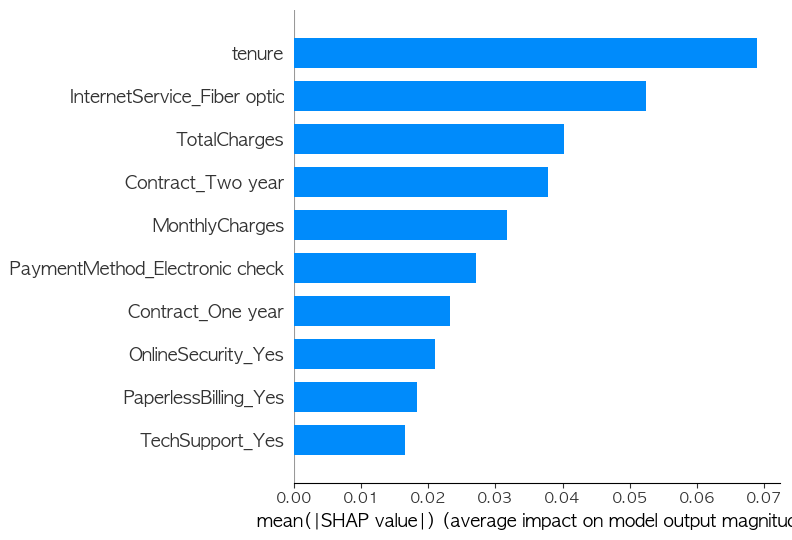

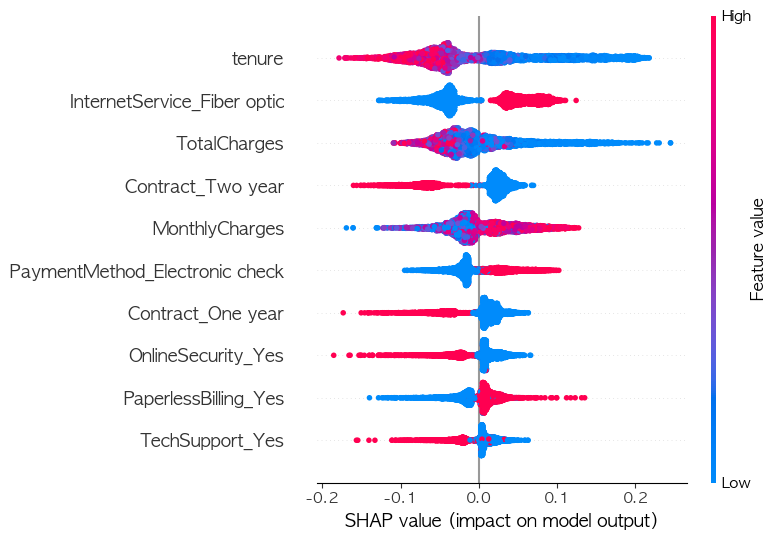

In [19]:
# (1) Bar plot: 변수별 평균 |SHAP| 크기 (중요도 순)
shap.summary_plot(
    shap_values_churn,
    X_train_scaled,
    plot_type="bar",
    max_display=10   # 상위 10개만 표시
)

# (2) Dot plot: 변수 중요도 + 값 크기/방향 (빨강=높을수록 이탈↑, 파랑=낮을수록 이탈↑)
shap.summary_plot(
    shap_values_churn,
    X_train_scaled,
    max_display=10
)

**[과제]** 써니는 실제로 이탈(Churn=1)로 예측된 고객 한 명을 골라서 Force Plot으로 어떤 변수들이 이탈 예측에 기여했는지 확인해보고자 합니다. AI를 활용해 관련 코드를 작성해보세요.

In [20]:
import shap
import numpy as np
import pandas as pd

# 1) 테스트셋에서 "이탈(1)"로 예측된 고객 찾기
Y_pred_test = rf_full.predict(X_test_scaled)
Y_proba_test = rf_full.predict_proba(X_test_scaled)[:, 1]

churn_pred_idx = np.where(Y_pred_test == 1)[0]
print(f"이탈로 예측된 고객 수: {len(churn_pred_idx)}")

# 예측 확률이 가장 높은 고객 1명 선택 (해석이 더 명확함)
selected_idx = churn_pred_idx[np.argmax(Y_proba_test[churn_pred_idx])]

x_sample = X_test_scaled.iloc[[selected_idx]]   # SHAP 계산용 (2D)
x_display = X_test_scaled.iloc[selected_idx]    # Force Plot 표시용 (1D)

print(f"\n=== 선택된 고객 (테스트셋 index={selected_idx}) ===")
print(f"예측: Churn={Y_pred_test[selected_idx]}")
print(f"예측 확률: {Y_proba_test[selected_idx]:.3f}")
print(f"실제 라벨: Churn={Y_test.iloc[selected_idx]}")

이탈로 예측된 고객 수: 277

=== 선택된 고객 (테스트셋 index=356) ===
예측: Churn=1
예측 확률: 1.000
실제 라벨: Churn=1


In [21]:
# 2) 해당 고객의 SHAP value 계산 (Churn=1 클래스 기준)
shap_single = explainer.shap_values(x_sample)

# shape: (1, 30, 2) → Churn=1 SHAP만 추출
shap_vals_churn = shap_single[0, :, 1]

# 기준값(base value): Churn=1 클래스
base_value_churn = explainer.expected_value[1]
print(f"Base value (Churn=1): {base_value_churn:.4f}")
print(f"예측 log-odds ≈ base + sum(SHAP) = {base_value_churn + shap_vals_churn.sum():.4f}")

Base value (Churn=1): 0.2651
예측 log-odds ≈ base + sum(SHAP) = 1.0000


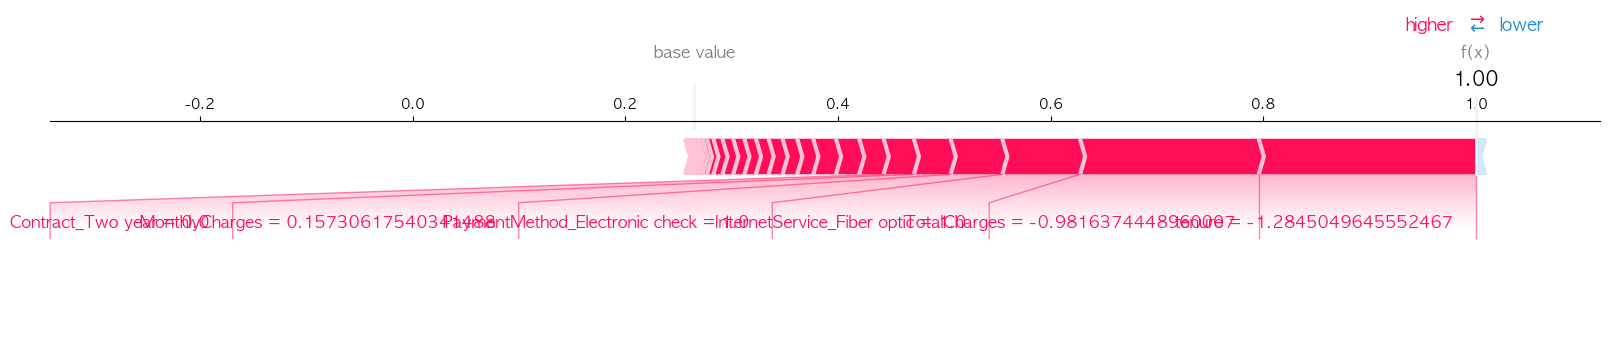

In [22]:
# 3) Force Plot (matplotlib 버전 — Jupyter에서 바로 표시)
shap.force_plot(
    base_value_churn,
    shap_vals_churn,
    x_display,
    matplotlib=True
)

In [23]:
# 4) (선택) 기여도 큰 변수 Top 10 표로 확인
contrib_df = pd.DataFrame({
    "feature": X_test_scaled.columns,
    "feature_value": x_display.values,
    "shap_value": shap_vals_churn
}).sort_values("shap_value", key=abs, ascending=False)

print("=== 이탈 예측에 기여한 변수 Top 10 ===")
display(contrib_df.head(10))

=== 이탈 예측에 기여한 변수 Top 10 ===


,feature,feature_value,shap_value
1,tenure,-1.284505,0.204276
3,TotalCharges,-0.981637,0.168055
10,InternetService_Fiber optic,True,0.073108
28,PaymentMethod_Electronic check,True,0.048596
2,MonthlyCharges,0.157306,0.034584
25,Contract_Two year,False,0.028396
13,OnlineSecurity_Yes,False,0.022993
19,TechSupport_Yes,False,0.021830
24,Contract_One year,False,0.021364
16,DeviceProtection_No internet service,False,0.015052


## 6) 분석 결과 종합 및 활용

**[과제]** 써니는 앞선 변수 선택 결과와 SHAP 분석을 종합해서, 이탈 고객을 막으려면 어떤 마케팅을 해야 할지 궁금합니다. AI와 상의하여 이탈로 예측된 고객들이 어떤 변수 때문에 그렇게 예측됐는지 파악하고 그에 맞는 마케팅 방식을 추천받아 보세요.

공통 핵심: tenure(가입 기간) — 세 방법 모두 1순위
mRMR ↔ SHAP 겹침: Fiber optic, Electronic check, 장기 계약 부재 → 행동 기반 이탈 신호
Boruta만 강조: MonthlyCharges, TotalCharges → 신규·저충성·고요금 고객군

mRMR는 5개 변수만으로 F1 0.521(전체 0.533의 98%)을 유지했으므로, 마케팅 타겟팅 변수로는 mRMR + SHAP 조합이 실무에 가장 적합합니다.

1. 이탈로 예측된 고객은 왜 그렇게 예측되었나?
테스트셋 277명이 이탈(1)로 예측되었고, 이 그룹의 SHAP·원본 데이터 패턴은 다음과 같습니다.

(1) 가입 기간이 짧다 — 가장 큰 요인
전역 SHAP 1위: tenure (mean |SHAP| ≈ 0.069)
이탈 예측군 평균 tenure: 10.7개월 vs 전체 테스트 32.5개월
Force Plot 대표 고객도 tenure SHAP +0.20 (가장 큼), 스케일 값 -1.28 → 평균보다 훨씬 짧은 신규 고객
→ 모델은 “오래 머문 고객 = 유지, 짧게 쓴 고객 = 이탈” 패턴을 강하게 학습했습니다.

(2) 장기 계약이 없다
100% Month-to-month(월 단위 계약)
Contract_Two year, Contract_One year = False일 때 SHAP ↑
mRMR에서도 Contract_Two year가 핵심 변수로 선택됨
→ 약정 없이 쓰는 고객은 이탈 예측에 크게 기여합니다.

(3) 광케이블(Fiber optic) + 높은 월요금
이탈 예측군 **83%**가 Fiber optic (전체 대비 매우 높음)
월요금 평균 $77.6 vs 전체 $63.7
InternetService_Fiber optic SHAP 2위, MonthlyCharges도 상위
→ 고가 요금제 + 광케이블 고객은 가격·품질·경쟁사 비교에 민감해 이탈 위험이 높게 잡힙니다.

(4) 전자수표(Electronic check) 결제
이탈 예측군 **69%**가 Electronic check
mRMR·SHAP 모두 상위 변수
→ 자동이체가 아닌 수동 결제는 이탈과 강하게 연관됩니다. (결제 불편, 약정 의지 낮음)

(5) 누적 요금·부가서비스 부족
TotalCharges 평균 $931 → 가입 기간이 짧아 충성도·락인(lock-in)이 낮음
Force Plot: OnlineSecurity_Yes=False, TechSupport_Yes=False → 보안·기술지원 미가입
SHAP에서 이 변수들도 이탈↑ 기여
→ 기본 인터넷만 쓰고 부가서비스·지원 채널을 쓰지 않는 고객은 이탈 가능성이 높습니다.

(6) PaperlessBilling
이탈 예측군 81% PaperlessBilling Yes
SHAP/mRMR에서 중간 정도 중요
→ 이탈 “원인”이라기보다 디지털 채널 사용 고객 비율이 높다는 신호입니다. 앱·이메일로 리텐션 접촉하기 좋은 세그먼트입니다.

대표 고객 Force Plot 해석 (예측 확률 100%, 실제 이탈)
변수	값	SHAP	의미
tenure
낮음
+0.20
신규 → 이탈↑
TotalCharges
낮음
+0.17
단기·저충성 → 이탈↑
Fiber optic
Yes
+0.07
광케이블 → 이탈↑
Electronic check
Yes
+0.05
수동결제 → 이탈↑
Contract_Two year
No
+0.03
무약정 → 이탈↑
OnlineSecurity/TechSupport
No
+0.02~
부가서비스 없음 → 이탈↑
한 줄 프로필:
“가입 1년 미만, 월 단위 계약, 광케이블, 전자수표 결제, 부가서비스 없는 고객”


2. 이탈을 막기 위한 마케팅 추천
우선순위별로 정리했습니다.

Priority 1 — 신규 고객 리텐션 (tenure)
대상: 가입 12개월 미만 (특히 3·6·9개월 구간)
근거: tenure가 모든 분석에서 1위, 이탈 예측군 평균 10.7개월

액션	내용
온보딩 프로그램
가입 1·3·6개월 시점 체크인 (설치 품질, 속도, 불만 확인)
이탈 조기 경보
predict_proba ≥ 0.7 + tenure < 12 → CS 선제 연락
로열티 마일스톤
6개월·1년 유지 시 요금 할인/데이터 추가
Priority 2 — 월 단위 → 장기 계약 전환 (Contract)
대상: Month-to-month 100%인 이탈 예측군
근거: mRMR Contract_Two year, SHAP에서 장기계약 부재가 이탈↑

액션	내용
업그레이드 프로모션
1년/2년 약정 시 월 $10~15 할인 또는 설치비 면제
이탈 직전 Retention Offer
해지 시도 시 “2년 약정 전환 + 3개월 20% 할인”
약정 만료 30일 전
자동 갱신 유도 + 장기 전환 인센티브
Priority 3 — Fiber optic 고객 가치·품질 관리
대상: Fiber optic + MonthlyCharges 상위 25%
근거: 이탈 예측군 83% Fiber, 월요금 $77.6

액션	내용
품질 보증
속도 미달 시 자동 보상, 무료 공유기 업그레이드
번들 할인
TV/스트리밍·보안 패키지 번들로 체감 가치 높이기
경쟁사 대응
타사 견적 제출 시 매칭 또는 추가 할인 (win-back)
Priority 4 — 결제 방식 개선 (Electronic check)
대상: Electronic check / Mailed check 결제 고객
근거: 이탈 예측군 69% Electronic check, mRMR·SHAP 공통

액션	내용
자동이체 전환 캠페인
신용카드/은행 자동이체 전환 시 $5/월 할인
결제 실패 알림
미납·결제 실패 즉시 SMS/앱 푸시 → CS 연결
페이퍼리스 + 자동결제 패키지
PaperlessBilling 고객(81%) 대상 원클릭 자동이체 유도
Priority 5 — 부가서비스 크로스셀 (OnlineSecurity, TechSupport)
대상: Fiber/DSL 사용 중 보안·기술지원 미가입
근거: SHAP Top 10, Force Plot에서 미가입 시 이탈↑

액션	내용
무료 체험
Online Security·Tech Support 1~3개월 무료
번들 패키지
“안심 인터넷 패키지” (보안+기술지원+백업)
이탈 위험 고객
고위험 예측 시 무료 기술 점검 제공
Priority 6 — 세그먼트별 실행 (실무 운영)
모델 점수와 SHAP 변수를 조합한 3단계 세그먼트 예시:

[고위험] predict_proba ≥ 0.7
  → tenure < 12 + Month-to-month + Fiber + Electronic check
  → 즉시 Retention Call + 약정/할인 Offer
[중위험] 0.4 ≤ proba < 0.7
  → 자동이체 전환 + 부가서비스 무료체험 이메일
[저위험] proba < 0.4
  → 일반 로열티 프로그램 (추천 리워드 등)
PaperlessBilling 고객(81%)은 앱 푸시·이메일이 효과적이고, Electronic check 고객은 전화·SMS 병행이 좋습니다.



결론 (미니프로젝트 보고용 한 문단)
변수 선택과 SHAP 분석 결과, 이탈 예측의 핵심은 짧은 가입 기간(tenure), 월 단위 계약, 광케이블·고월요금, 전자수표 결제, 부가서비스 미가입입니다. Boruta는 tenure·요금 중심의 가치·충성도 관점, mRMR와 SHAP는 계약·서비스·결제 행동 관점을 보여줍니다. 따라서 이탈 방지 마케팅은 ① 신규 고객 12개월 이내 집중 관리, ② 장기 약정 전환 인센티브, ③ Fiber 고객 품질·번들 강화, ④ 자동이체 전환, ⑤ 보안·기술지원 부가서비스 크로스셀 순으로 실행하는 것이 데이터와 가장 잘 맞습니다.